In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Device Setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("○ CPU")

np.random.seed(42)
torch.manual_seed(42)

print("\n" + "=" * 60)
print("         DOUBLE DESCENT - EINFACHE DEMONSTRATION")
print("=" * 60)

✓ Apple Silicon GPU (MPS)

         DOUBLE DESCENT - EINFACHE DEMONSTRATION


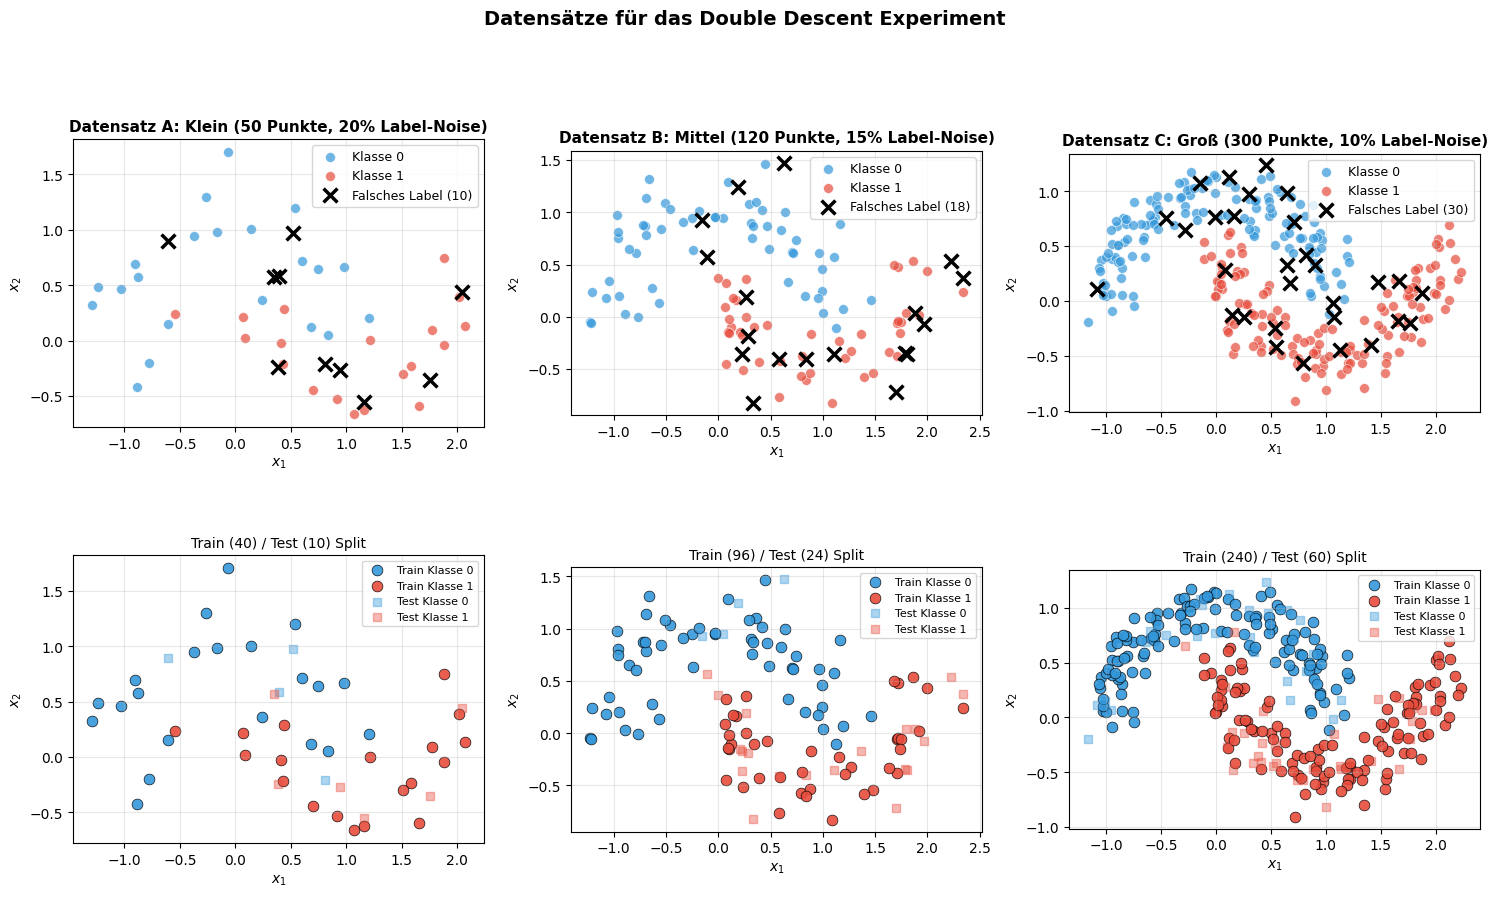

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# DREI DATENSÄTZE ERSTELLEN
# ═══════════════════════════════════════════════════════════════════════════════

def create_dataset(n_samples, noise, label_noise_rate, seed=42):
    """Erstellt Moon-Datensatz mit Label-Noise."""
    np.random.seed(seed)
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    # Label Noise
    n_flip = int(len(y) * label_noise_rate)
    flip_idx = np.random.choice(len(y), n_flip, replace=False)
    y_noisy = y.copy()
    y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
    
    # Split
    X_train, X_test, y_train, y_test_noisy = train_test_split(
        X, y_noisy, test_size=0.2, random_state=seed
    )
    _, _, _, y_test_true = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test_true,
        'X_all': X, 'y_all': y, 'y_noisy': y_noisy,
        'n_train': len(X_train)
    }

# Drei Datensätze
datasets = {
    'A': create_dataset(n_samples=50,  noise=0.25, label_noise_rate=0.20, seed=42),
    'B': create_dataset(n_samples=120, noise=0.20, label_noise_rate=0.15, seed=43),
    'C': create_dataset(n_samples=300, noise=0.15, label_noise_rate=0.10, seed=44),
}

dataset_info = {
    'A': 'Klein (50 Punkte, 20% Label-Noise)',
    'B': 'Mittel (120 Punkte, 15% Label-Noise)', 
    'C': 'Groß (300 Punkte, 10% Label-Noise)'
}

# ═══════════════════════════════════════════════════════════════════════════════
# DATENSÄTZE VISUALISIEREN
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for idx, (key, d) in enumerate(datasets.items()):
    # ─── OBERE REIHE: Alle Daten mit Label-Noise Markierung ───
    ax_top = axes[0, idx]
    
    X, y, y_noisy = d['X_all'], d['y_all'], d['y_noisy']
    correct = y == y_noisy
    
    # Korrekte Labels
    ax_top.scatter(X[correct & (y==0), 0], X[correct & (y==0), 1], 
                   c='#3498db', s=50, alpha=0.7, label='Klasse 0', edgecolors='white', linewidth=0.5)
    ax_top.scatter(X[correct & (y==1), 0], X[correct & (y==1), 1], 
                   c='#e74c3c', s=50, alpha=0.7, label='Klasse 1', edgecolors='white', linewidth=0.5)
    
    # Falsche Labels (mit X markiert)
    wrong_count = (~correct).sum()
    ax_top.scatter(X[~correct, 0], X[~correct, 1], 
                   c='black', marker='x', s=100, linewidths=2.5, 
                   label=f'Falsches Label ({wrong_count})', zorder=5)
    
    ax_top.set_title(f"Datensatz {key}: {dataset_info[key]}", fontsize=11, fontweight='bold')
    ax_top.legend(loc='upper right', fontsize=9)
    ax_top.grid(True, alpha=0.3)
    ax_top.set_xlabel('$x_1$')
    ax_top.set_ylabel('$x_2$')
    ax_top.set_aspect('equal')
    
    # ─── UNTERE REIHE: Train/Test Split ───
    ax_bot = axes[1, idx]
    
    X_train, y_train = d['X_train'], d['y_train']
    X_test, y_test = d['X_test'], d['y_test']
    
    # Trainingsdaten (größer, volle Farbe)
    ax_bot.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
                   c='#3498db', s=60, alpha=0.9, label='Train Klasse 0', 
                   edgecolors='black', linewidth=0.5, marker='o')
    ax_bot.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
                   c='#e74c3c', s=60, alpha=0.9, label='Train Klasse 1', 
                   edgecolors='black', linewidth=0.5, marker='o')
    
    # Testdaten (kleiner, blasser, anderer Marker)
    ax_bot.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
                   c='#3498db', s=30, alpha=0.4, label='Test Klasse 0', marker='s')
    ax_bot.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
                   c='#e74c3c', s=30, alpha=0.4, label='Test Klasse 1', marker='s')
    
    ax_bot.set_title(f"Train ({d['n_train']}) / Test ({len(X_test)}) Split", fontsize=10)
    ax_bot.legend(loc='upper right', fontsize=8)
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_xlabel('$x_1$')
    ax_bot.set_ylabel('$x_2$')
    ax_bot.set_aspect('equal')

plt.suptitle('Datensätze für das Double Descent Experiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# FLEXIBLES MLP - BELIEBIGE ARCHITEKTUR
# ═══════════════════════════════════════════════════════════════════════════════

class FlexibleMLP(nn.Module):
    """
    MLP mit beliebiger Architektur.
    
    Beispiele:
        FlexibleMLP([4])                    → 2-4-1 Netz
        FlexibleMLP([16, 16])               → 2-16-16-1 Netz  
        FlexibleMLP([400, 600, 1000, 600, 400]) → Tiefes Netz
    """
    def __init__(self, hidden_layers):
        super().__init__()
        
        if isinstance(hidden_layers, int):
            hidden_layers = [hidden_layers]
        
        layers = []
        in_dim = 2  # 2D Input
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            in_dim = h_dim
        
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.net = nn.Sequential(*layers)
        self.n_params = sum(p.numel() for p in self.parameters())
        self.architecture = hidden_layers
    
    def forward(self, x):
        return self.net(x)
    
    def __repr__(self):
        arch_str = "→".join(["2"] + [str(h) for h in self.architecture] + ["1"])
        return f"MLP({arch_str}) [{self.n_params} params]"


# ═══════════════════════════════════════════════════════════════════════════════
# DIE 5 NETZWERKE DEFINIEREN
# ═══════════════════════════════════════════════════════════════════════════════

NETWORKS = {
    'Winzig': {
        'hidden': [2],
        'color': '#3498db',
        'description': 'Minimal'
    },
    'Klein': {
        'hidden': [8],
        'color': '#9b59b6',
        'description': 'Einfach'
    },
    'Mittel': {
        'hidden': [32, 32],
        'color': '#f39c12',
        'description': '2 Hidden Layers'
    },
    'Groß': {
        'hidden': [64, 128, 64],
        'color': '#e74c3c',
        'description': '3 Hidden Layers'
    },
    'Riesig': {
        'hidden': [400, 600, 1000, 600, 400],
        'color': '#1abc9c',
        'description': '5 Hidden Layers, sehr tief'
    },
}

# Übersicht anzeigen
print("\n" + "=" * 70)
print("                         NETZWERK-ARCHITEKTUREN")
print("=" * 70)
print(f"{'Name':<10} {'Architektur':<30} {'Parameter':<12} {'Beschreibung'}")
print("-" * 70)

for name, cfg in NETWORKS.items():
    model = FlexibleMLP(cfg['hidden'])
    arch_str = "2→" + "→".join(map(str, cfg['hidden'])) + "→1"
    print(f"{name:<10} {arch_str:<30} {model.n_params:<12} {cfg['description']}")

print("-" * 70)



                         NETZWERK-ARCHITEKTUREN
Name       Architektur                    Parameter    Beschreibung
----------------------------------------------------------------------
Winzig     2→2→1                          9            Minimal
Klein      2→8→1                          33           Einfach
Mittel     2→32→32→1                      1185         2 Hidden Layers
Groß       2→64→128→64→1                  16833        3 Hidden Layers
Riesig     2→400→600→1000→600→400→1       1684201      5 Hidden Layers, sehr tief
----------------------------------------------------------------------


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING 
# ═══════════════════════════════════════════════════════════════════════════════

def train(model, X_train, y_train, X_test, y_test, epochs=5000, lr=0.01):
    """
    Einfaches Training OHNE jegliche Regularisierung.
    
    - Kein Weight Decay
    - Kein Dropout
    - Kein Early Stopping
    - Einfacher SGD
    """
    model = model.to(device)
    
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    X_te = torch.FloatTensor(X_test).to(device)
    y_te = torch.FloatTensor(y_test).reshape(-1, 1).to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)  # Einfacher SGD!
    
    history = {'epoch': [], 'train_loss': [], 'test_loss': [], 
               'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
        
        # Logging alle 100 Epochen
        if epoch % 100 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                tr_loss = criterion(model(X_tr), y_tr).item()
                te_loss = criterion(model(X_te), y_te).item()
                tr_acc = ((model(X_tr) > 0.5) == y_tr).float().mean().item()
                te_acc = ((model(X_te) > 0.5) == y_te).float().mean().item()
            
            history['epoch'].append(epoch)
            history['train_loss'].append(tr_loss)
            history['test_loss'].append(te_loss)
            history['train_acc'].append(tr_acc)
            history['test_acc'].append(te_acc)
    
    model = model.to('cpu')
    
    final = {
        'train_loss': history['train_loss'][-1],
        'test_loss': history['test_loss'][-1],
        'train_acc': history['train_acc'][-1],
        'test_acc': history['test_acc'][-1],
    }
    
    return model, history, final

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING ALLER KOMBINATIONEN
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("                         TRAINING STARTET")
print("=" * 70)
print(f"Device: {device}")
print(f"Netzwerke: {len(NETWORKS)}")
print(f"Datensätze: {len(datasets)}")
print(f"Gesamt: {len(NETWORKS) * len(datasets)} Trainingsläufe")
print("=" * 70)

results = {}

for dataset_key in ['A', 'B', 'C']:
    d = datasets[dataset_key]
    results[dataset_key] = {}
    
    print(f"\n{'─' * 70}")
    print(f"DATENSATZ {dataset_key}: {dataset_info[dataset_key]}")
    print(f"Train: {d['n_train']} Punkte → Interpolation-Schwelle: ~{d['n_train']} Parameter")
    print(f"{'─' * 70}")
    
    for net_name, net_cfg in NETWORKS.items():
        torch.manual_seed(42)
        model = FlexibleMLP(net_cfg['hidden'])
        n_params = model.n_params
        
        # Lernrate anpassen für sehr große Netze
        lr = 0.05 if n_params < 1000 else 0.01
        epochs = 20000
        
        print(f"  Training: {net_name:<10} ({n_params:>7} params)...", end=" ", flush=True)
        
        trained_model, history, final = train(
            model,
            d['X_train'], d['y_train'],
            d['X_test'], d['y_test'],
            epochs=epochs, lr=lr
        )
        
        results[dataset_key][net_name] = {
            'model': trained_model,
            'history': history,
            'final': final,
            'n_params': n_params,
            'color': net_cfg['color'],
            'architecture': net_cfg['hidden']
        }
        
        # Regime bestimmen
        ratio = n_params / d['n_train']
        if ratio < 0.5:
            regime = "UNDER"
        elif ratio < 1.5:
            regime = "INTER"
        else:
            regime = "OVER"
        
        print(f"[{regime:5s}] Train={final['train_loss']:.4f}, "
              f"Test={final['test_loss']:.4f}, Acc={final['test_acc']*100:.1f}%")

print("\n" + "=" * 70)
print("                      TRAINING ABGESCHLOSSEN")
print("=" * 70)


                         TRAINING STARTET
Device: mps
Netzwerke: 5
Datensätze: 3
Gesamt: 15 Trainingsläufe

──────────────────────────────────────────────────────────────────────
DATENSATZ A: Klein (50 Punkte, 20% Label-Noise)
Train: 40 Punkte → Interpolation-Schwelle: ~40 Parameter
──────────────────────────────────────────────────────────────────────
  Training: Winzig     (      9 params)... [UNDER] Train=0.3265, Test=0.4667, Acc=80.0%
  Training: Klein      (     33 params)... [INTER] Train=0.0938, Test=0.7973, Acc=80.0%
  Training: Mittel     (   1185 params)... [OVER ] Train=0.0515, Test=0.8428, Acc=80.0%
  Training: Groß       (  16833 params)... [OVER ] Train=0.0037, Test=1.7710, Acc=80.0%
  Training: Riesig     (1684201 params)... [OVER ] Train=0.0002, Test=2.7706, Acc=80.0%

──────────────────────────────────────────────────────────────────────
DATENSATZ B: Mittel (120 Punkte, 15% Label-Noise)
Train: 96 Punkte → Interpolation-Schwelle: ~96 Parameter
─────────────────────────

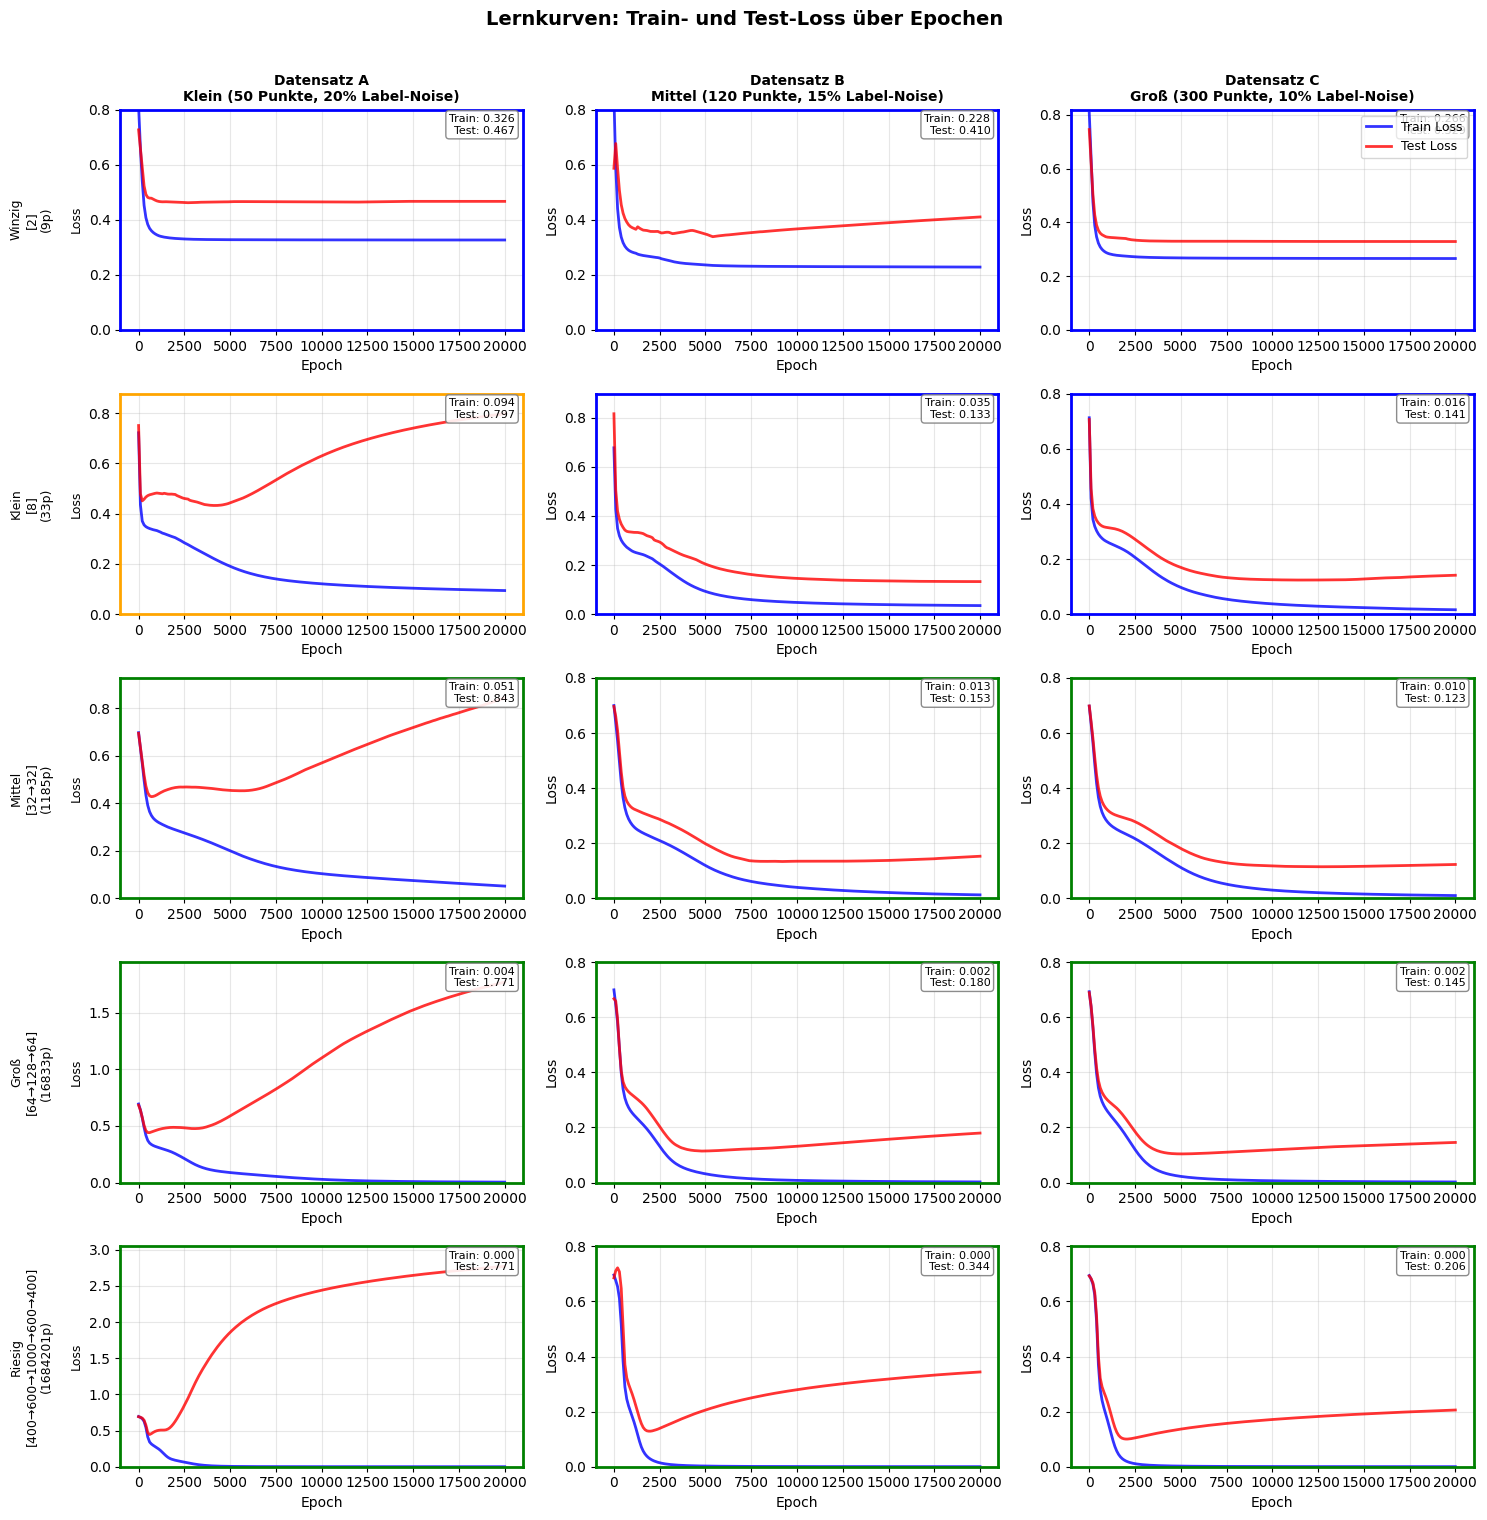

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# LERNKURVEN VISUALISIEREN
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(len(NETWORKS), 3, figsize=(15, 3*len(NETWORKS)))

for row_idx, net_name in enumerate(NETWORKS.keys()):
    for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
        ax = axes[row_idx, col_idx]
        
        r = results[dataset_key][net_name]
        h = r['history']
        
        # Loss-Kurven
        ax.plot(h['epoch'], h['train_loss'], 'b-', linewidth=2, 
                label='Train Loss', alpha=0.8)
        ax.plot(h['epoch'], h['test_loss'], 'r-', linewidth=2, 
                label='Test Loss', alpha=0.8)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, max(0.8, max(h['test_loss']) * 1.1)])
        
        # Titel für oberste Reihe
        if row_idx == 0:
            ax.set_title(f"Datensatz {dataset_key}\n{dataset_info[dataset_key]}", 
                        fontsize=10, fontweight='bold')
        
        # Y-Label für linke Spalte
        if col_idx == 0:
            arch_str = "→".join(map(str, r['architecture']))
            ax.set_ylabel(f"{net_name}\n[{arch_str}]\n({r['n_params']}p)\n\nLoss", fontsize=9)
        
        # Legende nur einmal
        if row_idx == 0 and col_idx == 2:
            ax.legend(loc='upper right', fontsize=9)
        
        # Finale Werte anzeigen
        ax.text(0.98, 0.98, 
                f"Train: {r['final']['train_loss']:.3f}\nTest: {r['final']['test_loss']:.3f}",
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round'))
        
        # Rahmenfarbe nach Regime
        n_train = datasets[dataset_key]['n_train']
        ratio = r['n_params'] / n_train
        if ratio < 0.5:
            color = 'blue'
        elif ratio < 1.5:
            color = 'orange'
        else:
            color = 'green'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

plt.suptitle('Lernkurven: Train- und Test-Loss über Epochen', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

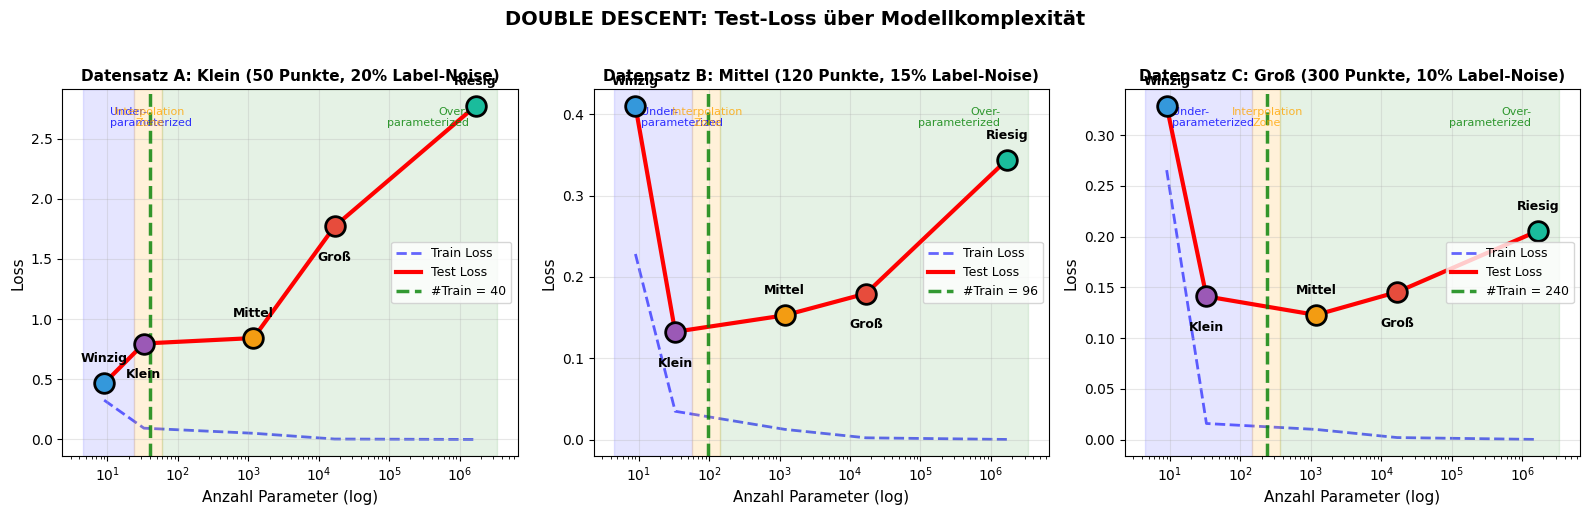

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# DOUBLE DESCENT KURVEN
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
    ax = axes[col_idx]
    d = datasets[dataset_key]
    n_train = d['n_train']
    
    # Daten sammeln
    params = []
    train_losses = []
    test_losses = []
    colors = []
    names = []
    
    for net_name in NETWORKS.keys():
        r = results[dataset_key][net_name]
        params.append(r['n_params'])
        train_losses.append(r['final']['train_loss'])
        test_losses.append(r['final']['test_loss'])
        colors.append(r['color'])
        names.append(net_name)
    
    # Sortieren nach Parameterzahl für korrekte Linienführung
    sort_idx = np.argsort(params)
    params_sorted = [params[i] for i in sort_idx]
    train_sorted = [train_losses[i] for i in sort_idx]
    test_sorted = [test_losses[i] for i in sort_idx]
    names_sorted = [names[i] for i in sort_idx]
    colors_sorted = [colors[i] for i in sort_idx]
    
    # Linien
    ax.plot(params_sorted, train_sorted, 'b--', linewidth=2, alpha=0.6, 
            label='Train Loss', zorder=1)
    ax.plot(params_sorted, test_sorted, 'r-', linewidth=3, 
            label='Test Loss', zorder=2)
    
    # Punkte mit Labels
    for i in range(len(params_sorted)):
        ax.scatter(params_sorted[i], test_sorted[i], c=colors_sorted[i], 
                   s=200, zorder=5, edgecolors='black', linewidth=2)
        
        # Label-Position anpassen
        offset = 15 if i % 2 == 0 else -25
        ax.annotate(names_sorted[i], 
                    (params_sorted[i], test_sorted[i]),
                    textcoords="offset points", xytext=(0, offset),
                    ha='center', fontsize=9, fontweight='bold')
    
    # Interpolation Threshold
    ax.axvline(x=n_train, color='green', linestyle='--', linewidth=2.5, 
               label=f'#Train = {n_train}', alpha=0.8)
    
    # Regime-Bereiche
    ax.axvspan(min(params) * 0.5, n_train * 0.6, alpha=0.1, color='blue')
    ax.axvspan(n_train * 0.6, n_train * 1.5, alpha=0.15, color='orange')
    ax.axvspan(n_train * 1.5, max(params) * 2, alpha=0.1, color='green')
    
    # Regime-Labels
    y_top = ax.get_ylim()[1] * 0.95
    ax.text(min(params) * 1.2, y_top, 'Under-\nparameterized', 
            fontsize=8, color='blue', alpha=0.8, va='top')
    ax.text(n_train, y_top, 'Interpolation\nZone', 
            fontsize=8, color='orange', alpha=0.8, ha='center', va='top')
    ax.text(max(params) * 0.8, y_top, 'Over-\nparameterized', 
            fontsize=8, color='green', alpha=0.8, ha='right', va='top')
    
    ax.set_xlabel('Anzahl Parameter (log)', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f"Datensatz {dataset_key}: {dataset_info[dataset_key]}", 
                 fontsize=11, fontweight='bold')
    ax.set_xscale('log')
    ax.legend(loc='center right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DOUBLE DESCENT: Test-Loss über Modellkomplexität', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

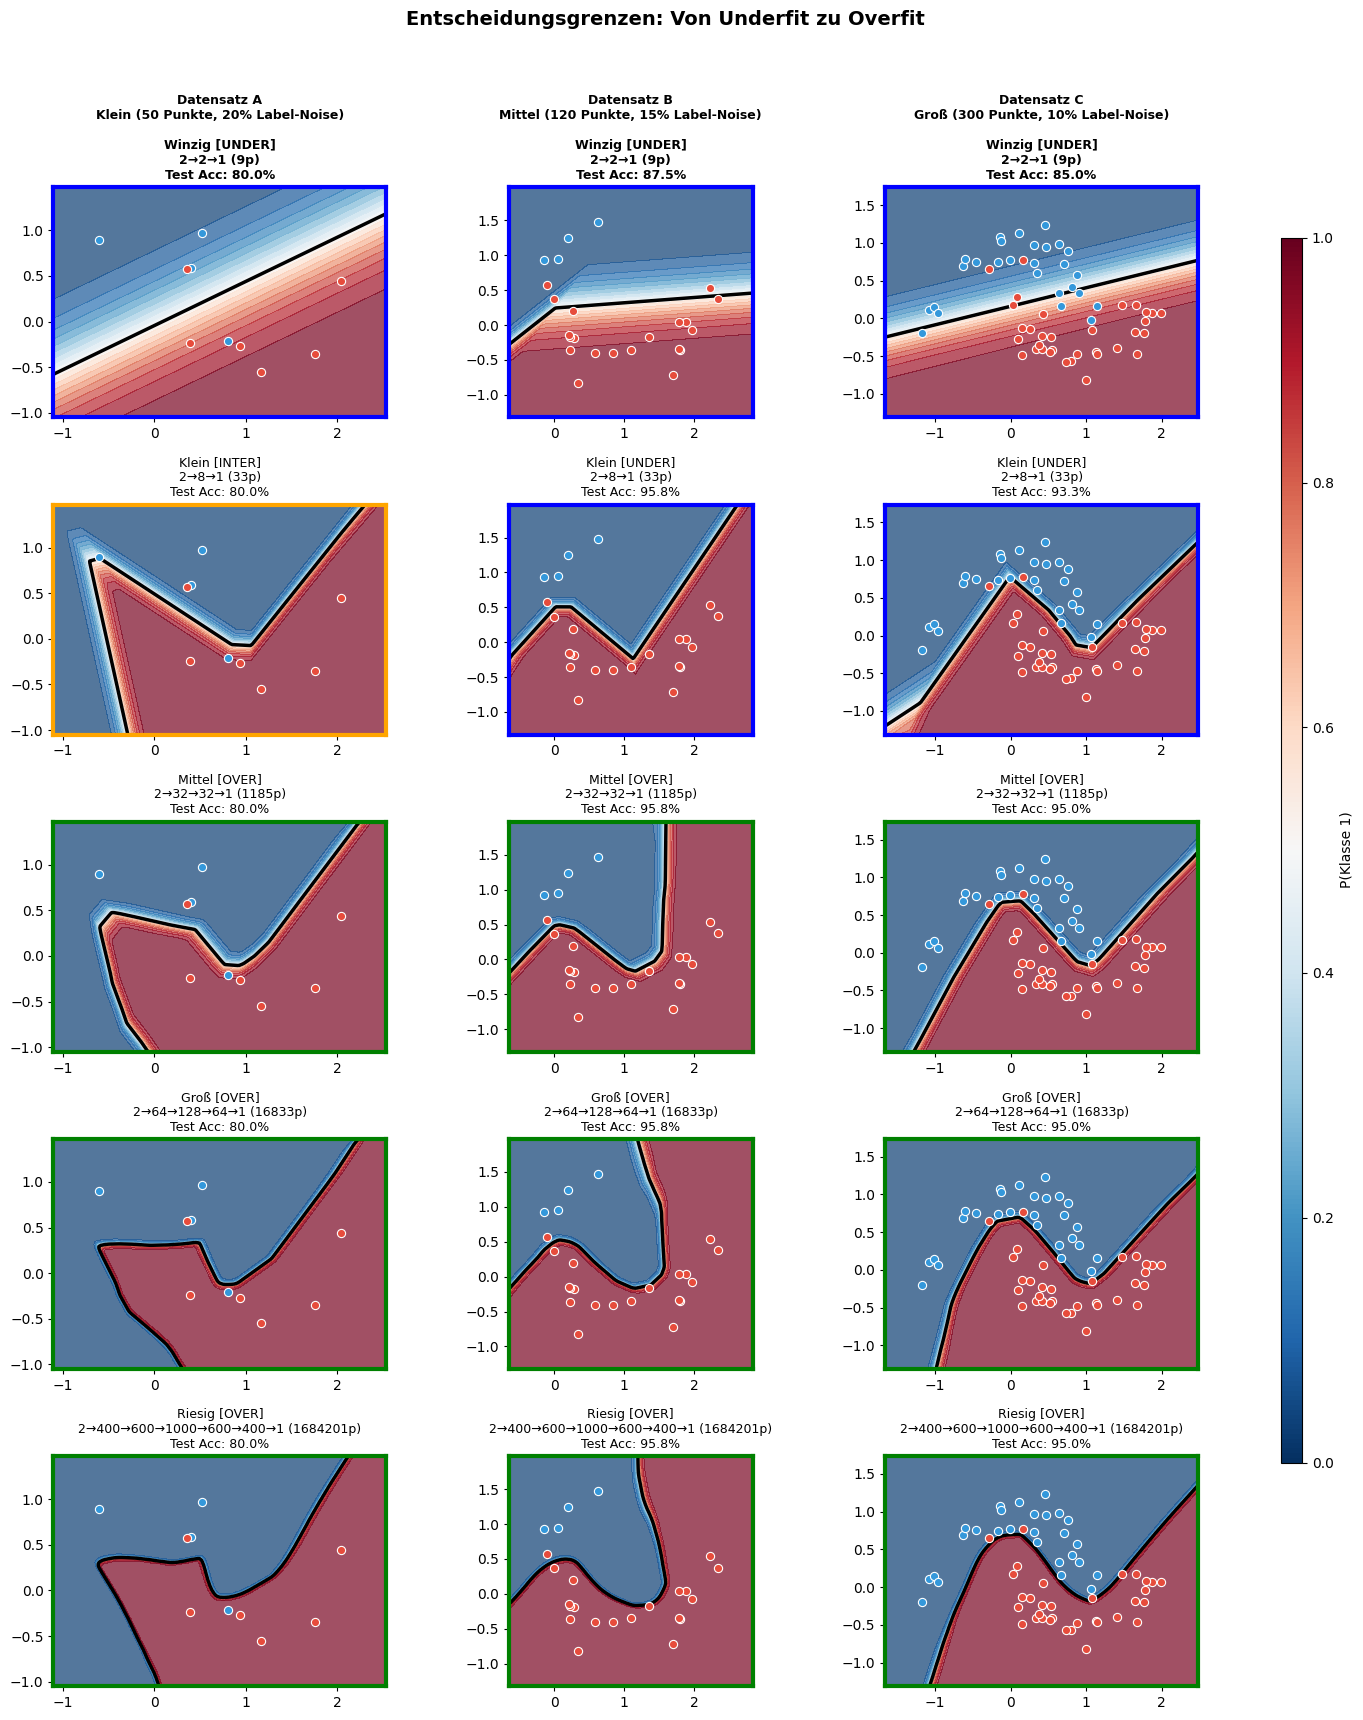

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENTSCHEIDUNGSGRENZEN VISUALISIEREN
# ═══════════════════════════════════════════════════════════════════════════════

def plot_decision_boundary(model, X, y, ax, title="", show_colorbar=False):
    """Plottet die Entscheidungsgrenze eines trainierten Modells."""
    model.eval()
    
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), 
                         np.arange(y_min, y_max, h))
    
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
    
    # Wahrscheinlichkeits-Heatmap
    contour = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), 
                          cmap='RdBu_r', alpha=0.7)
    
    # Entscheidungsgrenze
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5)
    
    # Datenpunkte
    ax.scatter(X[y==0, 0], X[y==0, 1], c='#3498db', s=35, 
               edgecolors='white', linewidth=0.8, zorder=5)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#e74c3c', s=35, 
               edgecolors='white', linewidth=0.8, zorder=5)
    
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    
    return contour


fig, axes = plt.subplots(len(NETWORKS), 3, figsize=(14, 3.5*len(NETWORKS)))

for row_idx, net_name in enumerate(NETWORKS.keys()):
    for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
        ax = axes[row_idx, col_idx]
        
        d = datasets[dataset_key]
        r = results[dataset_key][net_name]
        n_train = d['n_train']
        
        # Regime bestimmen
        ratio = r['n_params'] / n_train
        if ratio < 0.5:
            regime = "UNDER"
            regime_color = 'blue'
        elif ratio < 1.5:
            regime = "INTER"
            regime_color = 'orange'
        else:
            regime = "OVER"
            regime_color = 'green'
        
        # Architektur-String
        arch_str = "→".join(["2"] + [str(h) for h in r['architecture']] + ["1"])
        
        title = (f"{net_name} [{regime}]\n"
                 f"{arch_str} ({r['n_params']}p)\n"
                 f"Test Acc: {r['final']['test_acc']*100:.1f}%")
        
        contour = plot_decision_boundary(r['model'], d['X_test'], d['y_test'], ax, title)
        
        # Rahmen nach Regime färben
        for spine in ax.spines.values():
            spine.set_edgecolor(regime_color)
            spine.set_linewidth(3)
        
        # Spalten-Überschrift
        if row_idx == 0:
            ax.set_title(f"Datensatz {dataset_key}\n{dataset_info[dataset_key]}\n\n{title}", 
                        fontsize=9, fontweight='bold')

# Colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('P(Klasse 1)', fontsize=10)

plt.suptitle('Entscheidungsgrenzen: Von Underfit zu Overfit', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()

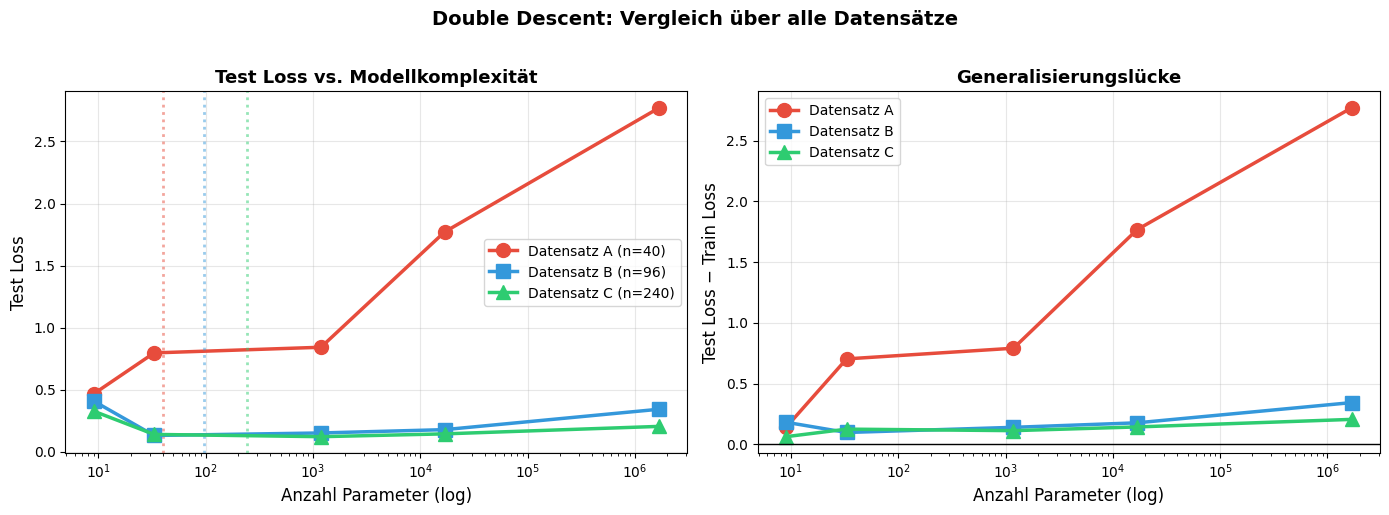

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# ZUSAMMENFASSENDE GRAFIK
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_ds = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71'}
markers_ds = {'A': 'o', 'B': 's', 'C': '^'}

# ─── PLOT 1: Test Loss Vergleich ───
ax1 = axes[0]

for dataset_key in ['A', 'B', 'C']:
    params = []
    test_losses = []
    
    for net_name in NETWORKS.keys():
        r = results[dataset_key][net_name]
        params.append(r['n_params'])
        test_losses.append(r['final']['test_loss'])
    
    # Sortieren
    sort_idx = np.argsort(params)
    params_s = [params[i] for i in sort_idx]
    losses_s = [test_losses[i] for i in sort_idx]
    
    n_train = datasets[dataset_key]['n_train']
    ax1.plot(params_s, losses_s, f'-{markers_ds[dataset_key]}', 
             color=colors_ds[dataset_key], linewidth=2.5, markersize=10,
             label=f"Datensatz {dataset_key} (n={n_train})")
    ax1.axvline(x=n_train, color=colors_ds[dataset_key], linestyle=':', 
                alpha=0.5, linewidth=2)

ax1.set_xlabel('Anzahl Parameter (log)', fontsize=12)
ax1.set_ylabel('Test Loss', fontsize=12)
ax1.set_title('Test Loss vs. Modellkomplexität', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ─── PLOT 2: Generalisierungslücke ───
ax2 = axes[1]

for dataset_key in ['A', 'B', 'C']:
    params = []
    gaps = []
    
    for net_name in NETWORKS.keys():
        r = results[dataset_key][net_name]
        params.append(r['n_params'])
        gaps.append(r['final']['test_loss'] - r['final']['train_loss'])
    
    sort_idx = np.argsort(params)
    params_s = [params[i] for i in sort_idx]
    gaps_s = [gaps[i] for i in sort_idx]
    
    ax2.plot(params_s, gaps_s, f'-{markers_ds[dataset_key]}', 
             color=colors_ds[dataset_key], linewidth=2.5, markersize=10,
             label=f"Datensatz {dataset_key}")

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Anzahl Parameter (log)', fontsize=12)
ax2.set_ylabel('Test Loss − Train Loss', fontsize=12)
ax2.set_title('Generalisierungslücke', fontsize=13, fontweight='bold')
ax2.set_xscale('log')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Double Descent: Vergleich über alle Datensätze', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()